# Goalkeeper Market Value Prediction: Model Comparison

This notebook loads the engineered features, trains multiple regression models, compares their performance, and selects the best model for predicting goalkeeper market values.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load features and target
X = pd.read_csv('../Data/gk_features_for_modeling.csv', index_col=0)
y = pd.read_csv('../Data/gk_target_for_modeling.csv', index_col=0)

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (140, 138)
Target shape: (140, 1)


## 2. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Train shape: (112, 138) (112, 1)
Test shape: (28, 138) (28, 1)


## 3. Model Training and Evaluation

Linear Regression: RMSE=12032107.13, R2=-4.717
Ridge: RMSE=6094353.20, R2=-0.467
Lasso: RMSE=11496624.67, R2=-4.219
Decision Tree: RMSE=7900367.31, R2=-1.465
Random Forest: RMSE=5083066.74, R2=-0.020


c:\Projects\myenv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Projects\myenv\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Gradient Boosting: RMSE=5433558.51, R2=-0.166
AdaBoost: RMSE=5311602.25, R2=-0.114
SVR: RMSE=5032509.50, R2=-0.000


c:\Projects\myenv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Projects\myenv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\azedd\AppData\Local\Temp\ipykernel_4760\2794253099.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')


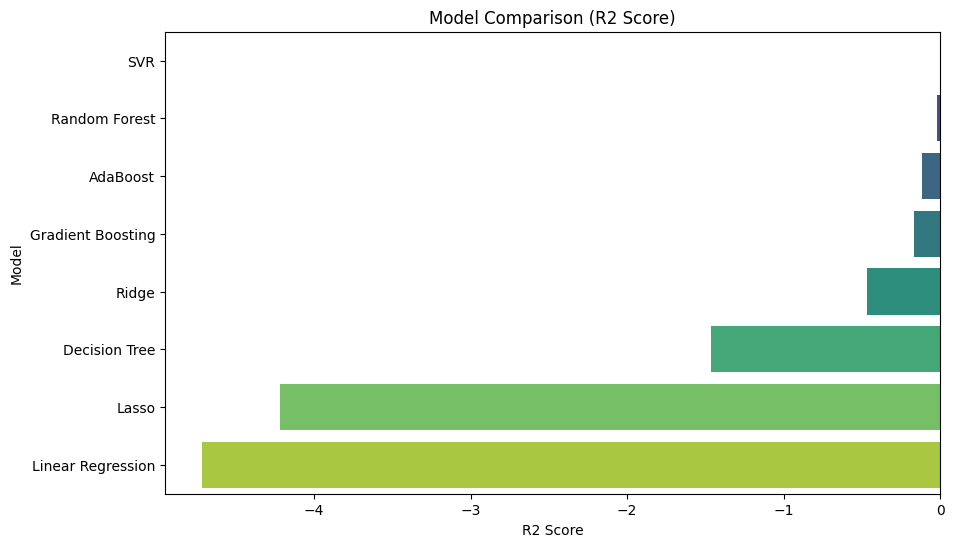

C:\Users\azedd\AppData\Local\Temp\ipykernel_4760\2794253099.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')


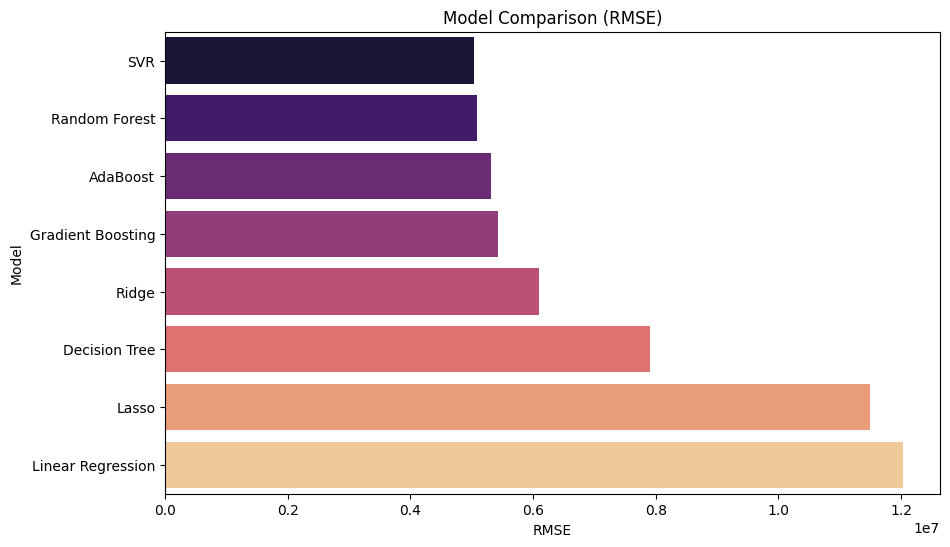

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'SVR': SVR()
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
    print(f'{name}: RMSE={rmse:.2f}, R2={r2:.3f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison (R2 Score)')
plt.xlabel('R2 Score')
plt.ylabel('Model')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')
plt.title('Model Comparison (RMSE)')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.show()

## 4. Best Model Selection and Conclusion

In [9]:
best_model = results_df.iloc[0]
print(f"Best Model: {best_model['Model']} (R2={best_model['R2']:.3f}, RMSE={best_model['RMSE']:.2f})")

Best Model: SVR (R2=-0.000, RMSE=5032509.50)
